# Oxford Pets Image Classification

**Deep Learning and Big Data Final Project**

In this notebook, we work with the Oxford-IIIT Pet dataset and build image classification models using PyTorch.

The project has two main goals:

1. Classify pet breeds using 37 classes.
2. Classify images as cat or dog.

We compare two approaches:

- a CNN trained from scratch
- a ResNet18 transfer learning model

The notebook shows the dataset, model setup, full experiment training, evaluation results, and the final figures used in our report and presentation.


## 0. Setup

Run this cell first to import the libraries used in the notebook.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torchvision import datasets

# Import project files from src/oxpets.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src" / "oxpets").exists() and (PROJECT_ROOT / "oxford_pets_project").exists():
    PROJECT_ROOT = PROJECT_ROOT / "oxford_pets_project"

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from oxpets.config import CHECKPOINT_DIR, DATA_DIR, FIGURES_DIR, METRICS_DIR, TrainConfig, ensure_output_dirs, select_device, set_seed
from oxpets.data import BREED_CLASSES, SPECIES_CLASSES, make_loaders
from oxpets.metrics import compute_metrics, save_confusion_matrix, save_history_plot, save_summary_barplot
from oxpets.models import build_scratch_model, build_transfer_model, unfreeze_final_resnet_block
from oxpets.train import evaluate, train_model, trainable_parameters

ensure_output_dirs()
set_seed(42)

device = select_device()
print("Using device:", device)
print("Project folder:", PROJECT_ROOT.name)


Using device: mps
Project folder: oxford_pets_project


## 1. Dataset Check

Here we check that the images are loaded from the real Oxford Pets data folder and that the breed and species labels are correct.


In [2]:
raw_dataset = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types=["category", "binary-category"],
    transform=None,
    download=True,
)

print("Dataset folder:", DATA_DIR / "oxford-iiit-pet" / "images")
print("Number of trainval images:", len(raw_dataset))
print("Number of breed classes:", len(raw_dataset.classes))
print("Species classes:", raw_dataset.bin_classes)
print("First image path:", raw_dataset._images[0])
print("First five breed classes:", raw_dataset.classes[:5])
print("Project breed labels match Torchvision:", BREED_CLASSES == raw_dataset.classes)
print("Project species labels:", SPECIES_CLASSES)


Dataset folder: /Users/luvsharma/Desktop/DeepLearning/oxford_pets_project/data/oxford-iiit-pet/images
Number of trainval images: 3680
Number of breed classes: 37
Species classes: ['Cat', 'Dog']
First image path: /Users/luvsharma/Desktop/DeepLearning/oxford_pets_project/data/oxford-iiit-pet/images/Abyssinian_100.jpg
First five breed classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']
Project breed labels match Torchvision: True
Project species labels: ['cat', 'dog']


## 2. Real Image Examples

These examples come directly from the Oxford Pets image folder. Each title shows the breed and the species label.


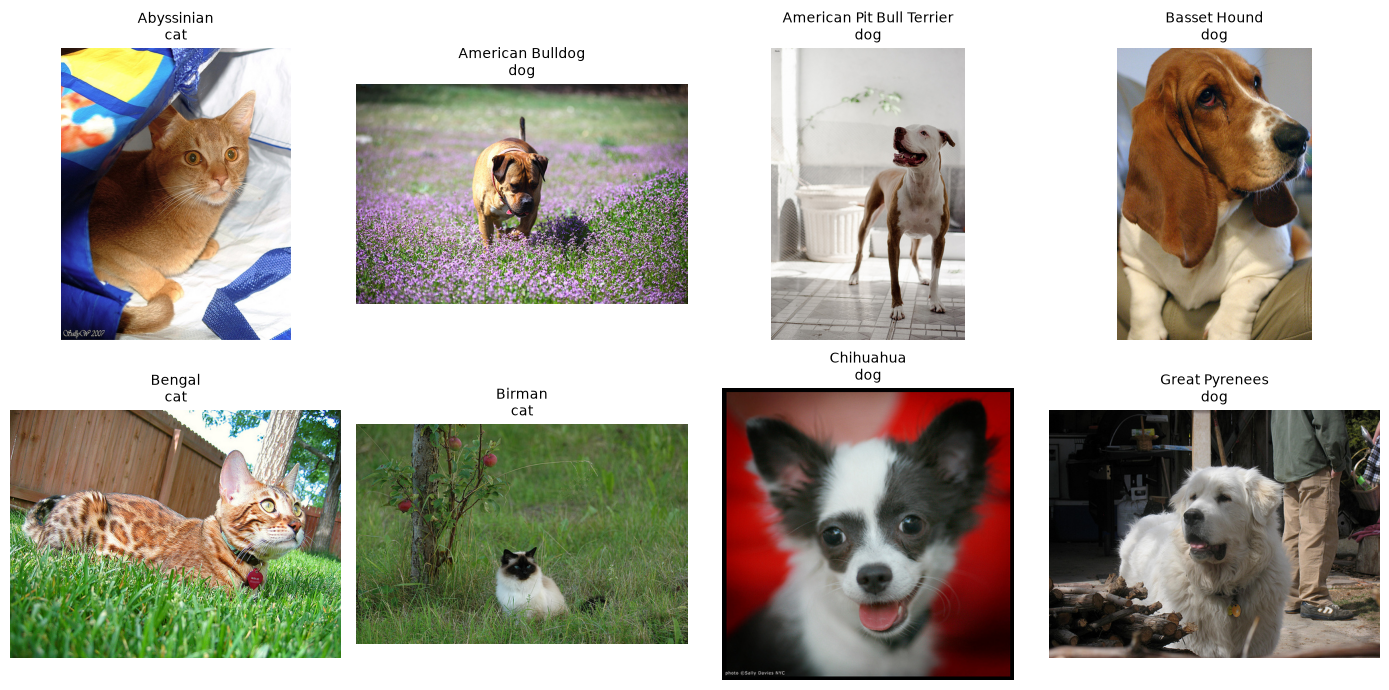

In [3]:
selected_indices = [0, 50, 100, 180, 260, 340, 520, 760]

plt.figure(figsize=(14, 7))
for plot_id, index in enumerate(selected_indices, start=1):
    image, (breed_label, species_label) = raw_dataset[index]
    breed_name = BREED_CLASSES[int(breed_label)]
    species_name = SPECIES_CLASSES[int(species_label)]

    plt.subplot(2, 4, plot_id)
    plt.imshow(image)
    plt.title(f"{breed_name}\n{species_name}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 3. Dataloaders and Model Output

For training, images are resized and converted to tensors. The output layer changes with the task: 37 logits for breed classification and 2 logits for cat vs dog classification.


In [4]:
model_check_config = TrainConfig(image_size=160, batch_size=8, num_workers=0)

for task in ["breed", "species"]:
    train_loader, val_loader, test_loader, spec = make_loaders(
        task=task,
        config=model_check_config,
        download=False,
    )
    images, labels = next(iter(train_loader))

    scratch_model = build_scratch_model(spec.num_classes)
    transfer_model = build_transfer_model(spec.num_classes, pretrained=False)

    with torch.no_grad():
        scratch_output = scratch_model(images)
        transfer_output = transfer_model(images)

    print(f"{task} task")
    print("  classes:", spec.num_classes)
    print("  image batch:", tuple(images.shape))
    print("  scratch output:", tuple(scratch_output.shape))
    print("  transfer output:", tuple(transfer_output.shape))


breed task
  classes: 37
  image batch: (8, 3, 160, 160)
  scratch output: (8, 37)
  transfer output: (8, 37)
species task
  classes: 2
  image batch: (8, 3, 160, 160)
  scratch output: (8, 2)
  transfer output: (8, 2)


## 4. Final Experiments

We now train all four project combinations. This is the full experiment setup used for the report and presentation.

- breed + scratch CNN
- breed + transfer learning
- species + scratch CNN
- species + transfer learning


In [5]:
EXPERIMENTS = [
    {
        "task": "breed",
        "model": "scratch",
        "epochs": 8,
        "fine_tune_epochs": 0,
        "batch_size": 32,
        "image_size": 160,
    },
    {
        "task": "breed",
        "model": "transfer",
        "epochs": 5,
        "fine_tune_epochs": 3,
        "batch_size": 32,
        "image_size": 160,
    },
    {
        "task": "species",
        "model": "scratch",
        "epochs": 8,
        "fine_tune_epochs": 0,
        "batch_size": 32,
        "image_size": 160,
    },
    {
        "task": "species",
        "model": "transfer",
        "epochs": 5,
        "fine_tune_epochs": 3,
        "batch_size": 32,
        "image_size": 160,
    },
]


def run_experiment(settings):
    task = settings["task"]
    model_name = settings["model"]
    run_name = f"{task}_{model_name}"

    print(f"\n=== {run_name} ===")
    config = TrainConfig(batch_size=settings["batch_size"], image_size=settings["image_size"], num_workers=0)
    train_loader, val_loader, test_loader, spec = make_loaders(
        task,
        config,
        download=False,
    )

    # The scratch CNN learns all visual features from the Oxford Pets images.
    if model_name == "scratch":
        model = build_scratch_model(spec.num_classes)
    else:
        # The transfer model starts from ResNet18 image features and replaces the classifier head.
        model = build_transfer_model(spec.num_classes, freeze_backbone=True, pretrained=True)

    model = model.to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(trainable_parameters(model), lr=0.001, weight_decay=0.0001)

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=loss_function,
        optimizer=optimizer,
        device=device,
        epochs=settings["epochs"],
    )

    if model_name == "transfer" and settings["fine_tune_epochs"] > 0:
        print("Fine-tuning the final ResNet block")
        unfreeze_final_resnet_block(model)
        optimizer = torch.optim.AdamW(trainable_parameters(model), lr=0.0001, weight_decay=0.0001)
        history.extend(
            train_model(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=loss_function,
                optimizer=optimizer,
                device=device,
                epochs=settings["fine_tune_epochs"],
                start_epoch=len(history) + 1,
            )
        )

    test_loss, test_accuracy, y_true, y_pred = evaluate(model, test_loader, loss_function, device)
    metrics = compute_metrics(y_true, y_pred, spec.class_names)
    metrics.update({
        "task": task,
        "model": model_name,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "test_macro_f1": float(metrics["macro_f1"]),
        "num_test_samples": len(y_true),
    })

    pd.DataFrame(history).to_csv(METRICS_DIR / f"{run_name}_history.csv", index=False)
    with (METRICS_DIR / f"{run_name}_metrics.json").open("w", encoding="utf-8") as handle:
        json.dump(metrics, handle, indent=2)

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "task": task,
            "model": model_name,
            "class_names": spec.class_names,
            "metrics": metrics,
        },
        CHECKPOINT_DIR / f"{run_name}.pt",
    )

    save_history_plot(history, FIGURES_DIR / f"{run_name}_history.png", f"{task} {model_name} training")
    save_confusion_matrix(
        y_true,
        y_pred,
        spec.class_names,
        FIGURES_DIR / f"{run_name}_confusion_matrix.png",
        f"{task} {model_name} confusion matrix",
    )

    print(f"Test accuracy: {test_accuracy:.3f}")
    print(f"Macro F1: {metrics['macro_f1']:.3f}")
    return metrics


all_metrics = [run_experiment(settings) for settings in EXPERIMENTS]



=== breed_scratch ===


train:   0%|          | 0/92 [00:00<?, ?it/s]

eval:   0%|          | 0/23 [00:00<?, ?it/s]

epoch 01 | train loss 3.5993 acc 0.040 | val loss 3.5000 acc 0.075


train:   0%|          | 0/92 [00:00<?, ?it/s]

...

train:   0%|          | 0/92 [00:00<?, ?it/s]

eval:   0%|          | 0/23 [00:00<?, ?it/s]

epoch 08 | train loss 0.0233 acc 0.992 | val loss 0.0273 acc 0.988


eval:   0%|          | 0/115 [00:00<?, ?it/s]

Test accuracy: 0.984
Macro F1: 0.982


## 5. Compare Results

Accuracy gives the overall percentage of correct predictions. Macro F1 is also useful because it treats all classes more equally, which matters for the 37-class breed task.


In [6]:
summary = pd.DataFrame([
    {
        "task": row["task"],
        "model": row["model"],
        "test_loss": row["test_loss"],
        "test_accuracy": row["test_accuracy"],
        "test_macro_f1": row["test_macro_f1"],
        "num_test_samples": row["num_test_samples"],
    }
    for row in all_metrics
])
summary.to_csv(METRICS_DIR / "model_comparison_summary.csv", index=False)
save_summary_barplot(METRICS_DIR / "model_comparison_summary.csv", FIGURES_DIR / "model_comparison_summary.png")
summary


,task,model,test_loss,test_accuracy,test_macro_f1,num_test_samples
0,breed,scratch,3.243791,0.092123,0.055781,3669
1,breed,transfer,0.438341,0.860180,0.859265,3669
2,species,scratch,0.486579,0.758790,0.681883,3669
3,species,transfer,0.040674,0.984192,0.981837,3669


## 6. Final Figures

These figures are generated from the project code after training. They are also used in the report and presentation.


Figure not found: dataset_sample_grid.png
Figure not found: dataset_label_distribution.png
Figure not found: augmentation_preview.png


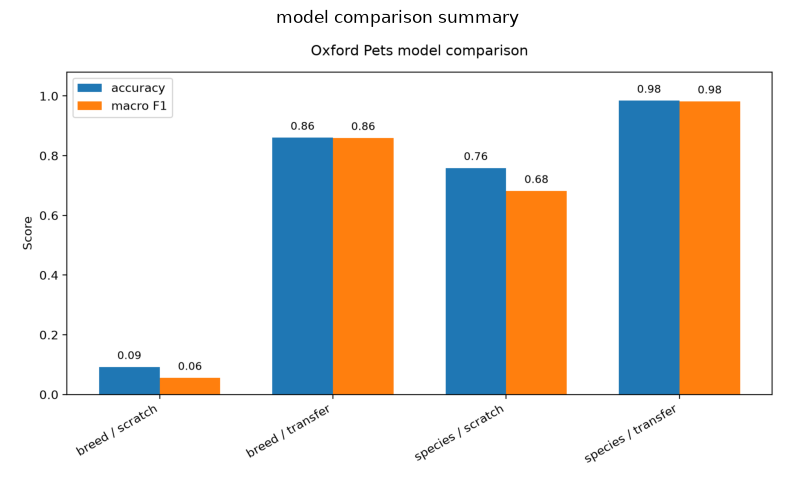

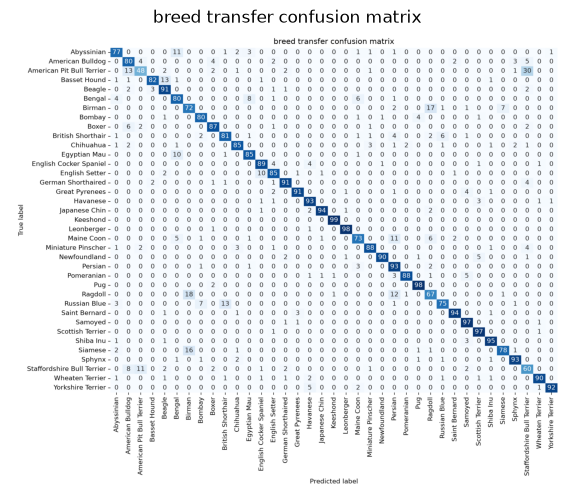

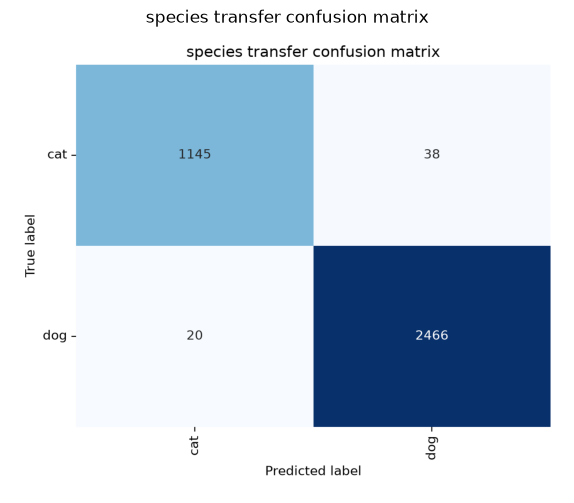

Figure not found: breed_transfer_prediction_grid.png
Figure not found: species_transfer_prediction_grid.png


In [7]:
figures = [
    "dataset_sample_grid.png",
    "dataset_label_distribution.png",
    "augmentation_preview.png",
    "model_comparison_summary.png",
    "breed_transfer_confusion_matrix.png",
    "species_transfer_confusion_matrix.png",
    "breed_transfer_prediction_grid.png",
    "species_transfer_prediction_grid.png",
]

for name in figures:
    path = FIGURES_DIR / name
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(name.replace("_", " ").replace(".png", ""))
        plt.show()
    else:
        print("Figure not found:", name)


## 7. Project Files

The report and presentation are included in the project folder.

- `reports/Project_Report.pdf`
- `slides/Project_Presentation.pdf`
